In [20]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from stillib_plotting import figure, use_style
from stillib_random import from_seed

from mscthesis.core.io import load_dataframe

use_style() 

root = from_seed(123456)

df = load_dataframe("./raw/devi_and_reddy_2018.csv")
df.head(10)

,genotype,surface,SD low VPD,SD low VPD error,SD high VPD,SD high VPD error,AL low VPD,AL low VPD error,AL high VPD,AL high VPD error,AW low VPD,AW low VPD error,AW high VPD,AW high VPD error
0,OL220,adaxial,150,6.02,257,9.32,13.20,1.25,7.10,1.98,3.93,0.08,4.69,0.11
1,LKT-57,adaxial,160,8.08,285,11.10,15.90,1.58,8.18,2.15,3.33,0.05,3.95,0.10
2,06-46-153P,adaxial,120,8.05,240,10.30,20.50,2.01,12.70,1.74,3.72,0.09,4.82,0.07
3,CS-50,adaxial,129,6.52,140,10.20,16.20,1.02,13.30,1.38,3.87,0.10,4.97,0.09
4,Siokra-L23,adaxial,100,5.29,213,9.30,19.80,2.05,15.10,1.98,3.77,0.09,4.86,0.10
5,OL220,abaxial,280,8.02,383,11.10,7.09,0.89,9.00,0.99,4.56,0.15,3.01,0.08
6,LKT-57,abaxial,280,5.29,400,9.30,12.10,1.45,14.30,1.56,3.43,0.09,2.89,0.21
7,06-46-153P,abaxial,244,6.02,343,9.32,14.10,0.85,15.00,1.46,4.32,0.12,2.41,0.09
8,CS-50,abaxial,250,8.02,260,10.30,14.60,0.98,15.70,1.78,3.68,0.10,2.03,0.09
9,Siokra-L23,abaxial,200,6.02,267,8.30,13.50,1.05,14.30,2.19,4.80,0.09,4.66,0.11


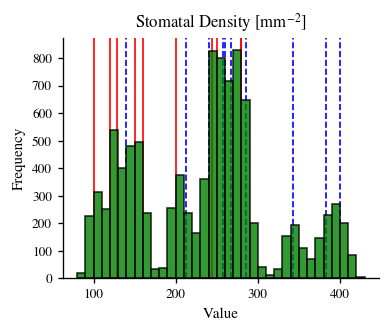

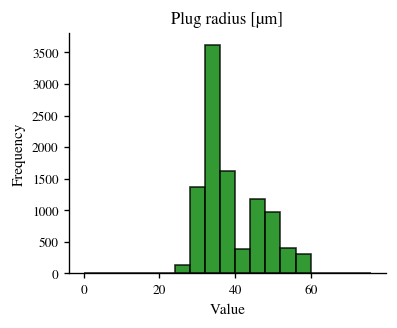

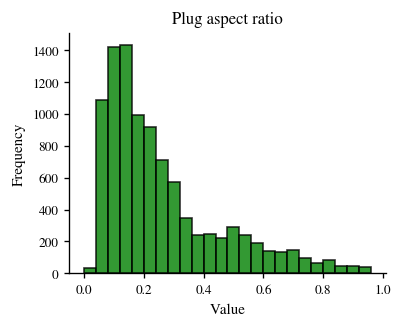

In [21]:
# combine SD low VPD and SD high VPD into a single array
sd = np.zeros(len(df) * 2)
sd_err = np.zeros(len(df) * 2)
sd[0::2] = df["SD low VPD"].to_numpy()
sd[1::2] = df["SD high VPD"].to_numpy()
sd_err[0::2] = df["SD low VPD error"].to_numpy()
sd_err[1::2] = df["SD high VPD error"].to_numpy()

def draw_values(rng: np.random.Generator, mean: float, std: float, n: int, positive: bool = True) -> np.ndarray:
    values = np.zeros(n) 
    index = 0
    while index < n:
        value = rng.normal(loc=mean, scale=std)
        if not positive or value > 0:
            values[index] = value
            index += 1
    return np.array(values)

def derive_data(rng: np.random.Generator, means: np.ndarray, stds: np.ndarray, n_samples: int) -> np.ndarray:
    data = np.zeros(len(means) * n_samples)
    index = 0
    for mean, std in zip(means, stds, strict=True):
        samples = draw_values(rng, mean, std, n_samples)
        data[index : index + n_samples] = samples
        index += n_samples
    return data

def plot_derived_data(data: np.ndarray, bins: np.ndarray, means: np.ndarray | None = None, title: str | None = None) -> None:
    fig, ax = figure()
    ax.hist(data, bins=bins.tolist(), alpha=0.8, edgecolor="black", color="g")
    if means is not None:
        for i, mean in enumerate(means):
            ax.axvline(mean, color="r" if i % 2 == 0 else "b", linestyle="-" if i % 2 == 0 else "--", linewidth=1, zorder=0)
    if title is not None:
        ax.set_title(title)
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")
    plt.show()

sd_stream = root.spawn("sd_stream")
sd_data = derive_data(sd_stream.generator(), sd, sd_err, n_samples=500)

# plot histogram of the generated data
plot_derived_data(sd_data, bins=np.arange(80, 440, 10), means=sd, title=r"Stomatal Density [mm$^{-2}$]")

# derive plug radius from stomatal density
# assuming spacing on a regular grid
area_per_stomata = 1 / sd_data # mm2 
spacing = 1000 * np.sqrt(area_per_stomata / np.pi) # µm

plot_derived_data(spacing, bins=np.arange(0, 80, 4), title="Plug radius [µm]")

# import mesophyll thickness distribution from Knauer
df_knauer = load_dataframe("./derived/Knauer_filtered.csv")
mesophyll_thickness = df_knauer["L"].to_numpy()

L_stream = root.spawn("L_stream1")
L_data = L_stream.generator().choice(mesophyll_thickness, size=spacing.size, replace=True)

plug_aspect = spacing / L_data 
plot_derived_data(plug_aspect, bins=np.arange(0, 1.0, 0.04), title="Plug aspect ratio")



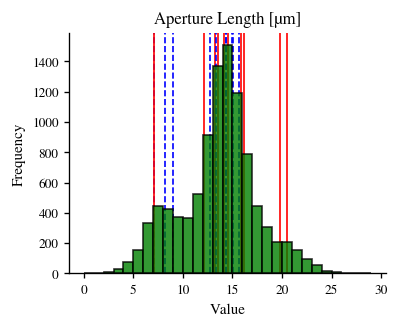

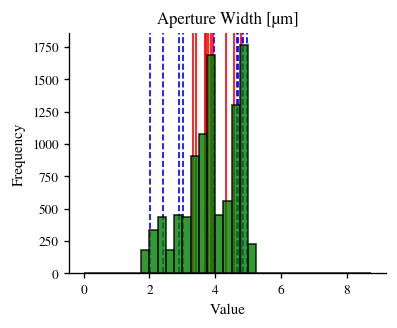

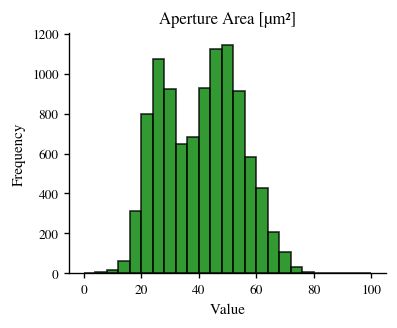

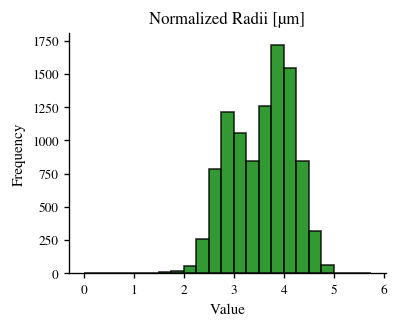

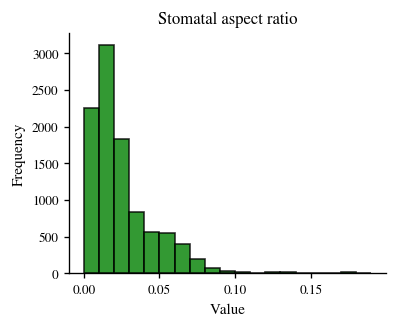

In [22]:
# Combine AL and AW into single arrays
al = np.zeros(len(df) * 2)
al_err = np.zeros(len(df) * 2)
aw = np.zeros(len(df) * 2)
aw_err = np.zeros(len(df) * 2)
al[0::2] = df["AL low VPD"].to_numpy()
al[1::2] = df["AL high VPD"].to_numpy()
al_err[0::2] = df["AL low VPD error"].to_numpy()
al_err[1::2] = df["AL high VPD error"].to_numpy()
aw[0::2] = df["AW low VPD"].to_numpy()
aw[1::2] = df["AW high VPD"].to_numpy()
aw_err[0::2] = df["AW low VPD error"].to_numpy()
aw_err[1::2] = df["AW high VPD error"].to_numpy()

al_data = derive_data(root.spawn("al_stream").generator(), al, al_err, n_samples=500)
plot_derived_data(al_data, bins=np.arange(0.0, 30.0, 1.0), means=al, title="Aperture Length [µm]")

aw_data = derive_data(root.spawn("aw_stream").generator(), aw, aw_err, n_samples=500)
plot_derived_data(aw_data, bins=np.arange(0.0, 9.0, 0.25), means=aw, title="Aperture Width [µm]")

areas = np.pi * al_data * aw_data / 4
plot_derived_data(areas, bins=np.arange(0.0, 104.0, 4.0), means=None, title="Aperture Area [µm²]")

radii = np.sqrt(areas / np.pi)
plot_derived_data(radii, bins=np.arange(0.0, 6.0, 0.25), means=None, title="Normalized Radii [µm]")

L_stream = root.spawn("L_stream2")
L_data = L_stream.generator().choice(mesophyll_thickness, size=radii.size, replace=True)

stomatal_aspect = radii / L_data 
plot_derived_data(stomatal_aspect, bins=np.arange(0, 0.2, 0.01), title="Stomatal aspect ratio")


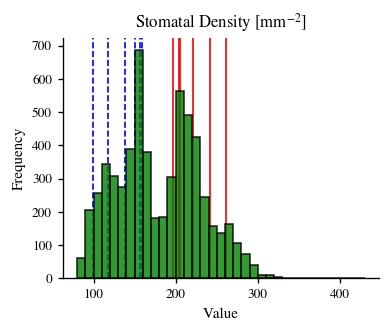

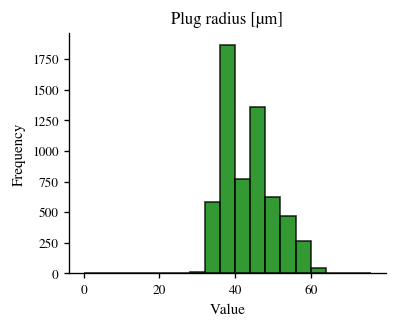

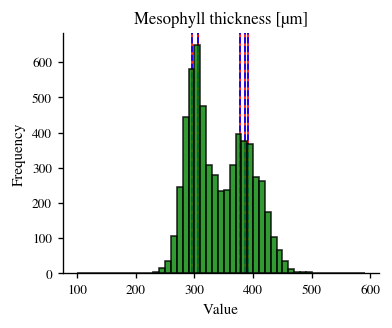

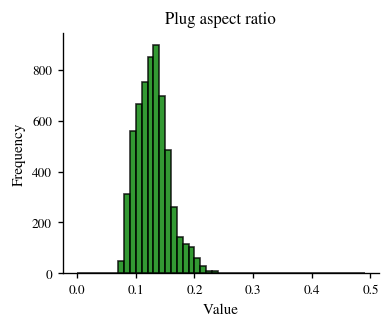

In [26]:
# Luo et al. 2023 

df = load_dataframe("./raw/luo_et_al_2023.csv")

sd = np.zeros(len(df) * 2)
sd_err = np.zeros(len(df) * 2)
sd[0::2] = df["SD abaxial"].to_numpy()
sd[1::2] = df["SD adaxial"].to_numpy()
sd_err[0::2] = df["SD abaxial error"].to_numpy()
sd_err[1::2] = df["SD adaxial error"].to_numpy()

sd_data = derive_data(root.spawn("sd_stream2").generator(), sd, sd_err, n_samples=500)
plot_derived_data(sd_data, bins=np.arange(80, 440, 10), means=sd, title=r"Stomatal Density [mm$^{-2}$]")

area_per_stomata = 1 / sd_data # mm2
spacing = 1000 * np.sqrt(area_per_stomata / np.pi) # µm
plot_derived_data(spacing, bins=np.arange(0, 80, 4), title="Plug radius [µm]")


L = np.zeros_like(sd)
L_err = np.zeros_like(sd)
L[0::2] = df["T_mesophyll"].to_numpy()
L[1::2] = df["T_mesophyll"].to_numpy()
L_err[0::2] = df["T_mesophyll error"].to_numpy()
L_err[1::2] = df["T_mesophyll error"].to_numpy()

L_data = derive_data(root.spawn("L_stream3").generator(), L, L_err, n_samples=500)
plot_derived_data(L_data, bins=np.arange(100, 600, 10), means=L, title="Mesophyll thickness [µm]")

plug_aspect = spacing / L_data
plot_derived_data(plug_aspect, bins=np.arange(0, 0.5, 0.01), title="Plug aspect ratio")


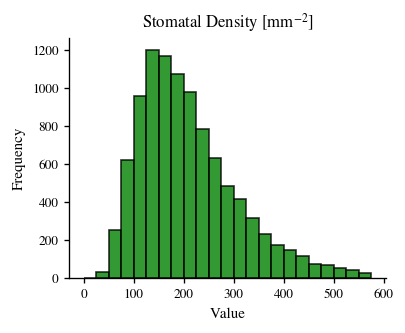

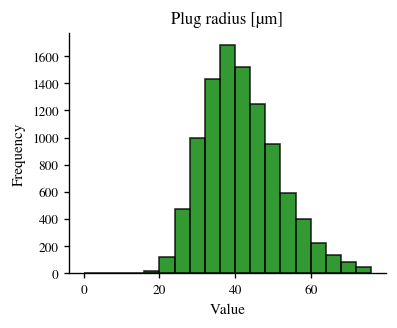

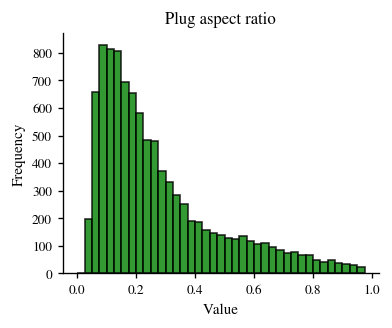

In [41]:
# liu et al. 2018 
import json 
with open("./raw/liu_et_al_2018.json") as f:
    data = json.load(f)

density_min   = data["density_min"]
density_mean  = data["density_mean"]
density_max   = data["density_max"]
log_norm_fwhm = data["log_norm_fwhm"]
log_norm_mean = np.log10(density_mean)

samples = root.spawn("liu_sd_stream").generator().normal(log_norm_mean, log_norm_fwhm / (2 * np.sqrt(2 * np.log(2))), size=10_000)
sd_data = 10**samples
plot_derived_data(sd_data, bins=np.arange(0, 600, 25), title=r"Stomatal Density [mm$^{-2}$]")

area_per_stomata = 1 / sd_data # mm2
spacing = 1000 * np.sqrt(area_per_stomata / np.pi) # µm
plot_derived_data(spacing, bins=np.arange(0, 80, 4), title="Plug radius [µm]")

mesophyll_thickness = df_knauer["L"].to_numpy()
L_data = root.spawn("liu_L_stream").generator().choice(mesophyll_thickness, size=spacing.size, replace=True)
plug_aspect = spacing / L_data
plot_derived_data(plug_aspect, bins=np.arange(0, 1.0, 0.025), title="Plug aspect ratio")
